In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv(r"E:\Downloads\Excel_sheets\Admission_Predict_Ver1.1.csv")

In [4]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [6]:
df.duplicated().sum()

0

In [7]:
df.drop(columns=['Serial No.'],inplace=True)

In [8]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [11]:
X=df.iloc[:,0:-1]
y=df.iloc[:,-1]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
y_train.shape

(400,)

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [14]:
import tensorflow
import keras
from keras.layers import Dense
from keras import Sequential

In [23]:
model=Sequential()
#model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(7,activation='relu'))
model.add(Dense(1,activation='linear'))

In [24]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 7)                 56        
                                                                 
 dense_3 (Dense)             (None, 7)                 56        
                                                                 
 dense_4 (Dense)             (None, 1)                 8         
                                                                 
Total params: 120
Trainable params: 120
Non-trainable params: 0
_________________________________________________________________


In [25]:
model.compile(loss='mean_squared_error',optimizer='Adam')

In [26]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 [==============================] - 0s 12ms/step - loss: 1.2269 - val_loss: 1.0950
Epoch 2/100
10/10 [==============================] - 0s 5ms/step - loss: 0.9802 - val_loss: 0.8644
Epoch 3/100
10/10 [==============================] - 0s 5ms/step - loss: 0.7841 - val_loss: 0.6968
Epoch 4/100
10/10 [==============================] - 0s 5ms/step - loss: 0.6493 - val_loss: 0.5868
Epoch 5/100
10/10 [==============================] - 0s 5ms/step - loss: 0.5517 - val_loss: 0.4934
Epoch 6/100
10/10 [==============================] - 0s 5ms/step - loss: 0.4481 - val_loss: 0.3656
Epoch 7/100
10/10 [==============================] - 0s 5ms/step - loss: 0.3111 - val_loss: 0.2052
Epoch 8/100
10/10 [==============================] - 0s 5ms/step - loss: 0.1665 - val_loss: 0.0872
Epoch 9/100
10/10 [==============================] - 0s 5ms/step - loss: 0.0672 - val_loss: 0.0283
Epoch 10/100
10/10 [==============================] - 0s 5ms/step - loss: 0.0230 - val_loss: 0.0117
Epoch 11

In [27]:
y_pred=model.predict(X_test_scaled)

4/4 [==============================] - 0s 2ms/step


In [28]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.795480183730511

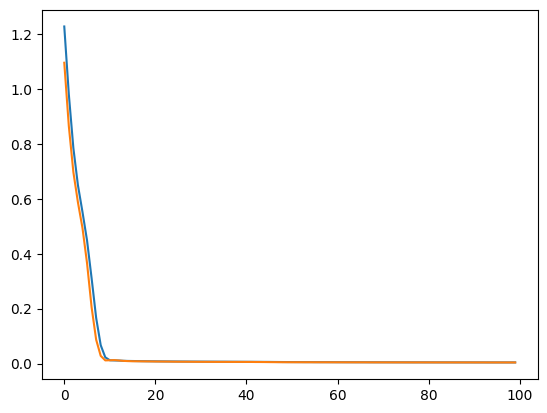

In [29]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])